<a href="https://colab.research.google.com/github/SanjuktaK/ssl-fundus-classification/blob/main/SSL_Fundus_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class CleanDatasetWrapper(Dataset):
    """A multiprocessing-safe wrapper that guarantees transforms are applied."""
    def __init__(self, base_dataset, indices, transform):
        self.samples = base_dataset.samples
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        sample = self.samples[self.indices[idx]]
        img = Image.open(sample["path"]).convert("RGB")
        img = self.transform(img)
        return img, torch.tensor(sample["labels"], dtype=torch.float32)

def finetune_and_evaluate(method_name, backbone_state):
    """
    Fine-tune a pretrained backbone and evaluate on test set.
    Returns: (model, test_metrics, y_true, y_prob, y_pred, history)
    """
    print(f"\n{'='*50}")
    print(f"  Fine-tuning: {method_name.upper()}")
    print(f"{'='*50}")

    # Define device inside the function
    device = torch.device(cfg.device)

    # Data Transforms
    train_aug = FinetuneAugmentation(cfg.image_size, is_train=True)
    val_aug = FinetuneAugmentation(cfg.image_size, is_train=False)
    loaders = get_dataloaders(mode="finetune")

    # Bulletproof Fix: Rebuild datasets using a safe wrapper to avoid pickling/tuple issues
    base_ds = loaders["full_dataset"]
    train_idx = loaders["train"].dataset.indices
    val_idx = loaders["val"].dataset.indices
    test_idx = loaders["test"].dataset.indices

    train_ds = CleanDatasetWrapper(base_ds, train_idx, train_aug)
    val_ds = CleanDatasetWrapper(base_ds, val_idx, val_aug)
    test_ds = CleanDatasetWrapper(base_ds, test_idx, val_aug)

    loaders["train"] = DataLoader(train_ds, batch_size=cfg.ft_batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
    loaders["val"] = DataLoader(val_ds, batch_size=cfg.ft_batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
    loaders["test"] = DataLoader(test_ds, batch_size=cfg.ft_batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)

    # Class weights
    weights = compute_class_weights(loaders["full_dataset"]).to(device)

    # Model
    backbone = get_backbone()
    backbone.load_state_dict(backbone_state)
    model = MultiLabelClassifier(backbone, dropout=cfg.ft_dropout,
                                  freeze=(cfg.ft_freeze_epochs > 0)).to(device)
    criterion = CombinedLoss(cfg.ft_bce_weight, cfg.ft_dice_weight,
                             cfg.ft_label_smoothing, weights)

    # Optimizer (only head when frozen)
    if cfg.ft_freeze_epochs > 0:
        opt = torch.optim.AdamW(model.head.parameters(), lr=cfg.ft_lr, weight_decay=cfg.ft_weight_decay)
    else:
        opt = torch.optim.AdamW(model.parameters(), lr=cfg.ft_lr, weight_decay=cfg.ft_weight_decay)

    sched = get_cosine_schedule(opt, cfg.ft_warmup_epochs, cfg.ft_epochs)
    scaler = GradScaler(enabled=cfg.mixed_precision)
    early = EarlyStopping(cfg.ft_early_stopping_patience)

    history = {"train_loss": [], "val_loss": [], "val_auc": []}

    for epoch in range(cfg.ft_epochs):
        # Train
        model.train()
        total_loss = 0
        for x, y in loaders["train"]:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            with autocast(enabled=cfg.mixed_precision):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.gradient_clip)
            scaler.step(opt)
            scaler.update()
            total_loss += loss.item()

        # Validate
        model.eval()
        val_loss, y_val_true, y_val_prob = 0, [], []
        with torch.no_grad():
            for x, y in loaders["val"]:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item()
                y_val_true.append(y.cpu().numpy())
                y_val_prob.append(torch.sigmoid(logits).cpu().numpy())

        y_val_true = np.concatenate(y_val_true)
        y_val_prob = np.concatenate(y_val_prob)
        val_metrics = compute_metrics(y_val_true, (y_val_prob >= cfg.ft_threshold).astype(float), y_val_prob)

        avg_train_loss = total_loss / len(loaders["train"])
        avg_val_loss = val_loss / len(loaders["val"])

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_auc"].append(val_metrics["auc_macro"])

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{cfg.ft_epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | AUC: {val_metrics['auc_macro']:.4f}")

        sched.step()

        # Unfreeze after freeze period
        if epoch == cfg.ft_freeze_epochs - 1:
            model.unfreeze()
            opt = torch.optim.AdamW(model.parameters(), lr=cfg.ft_lr, weight_decay=cfg.ft_weight_decay)

        if early(avg_val_loss):
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Evaluate on test set
    model.eval()
    y_test_true, y_test_prob = [], []
    with torch.no_grad():
        for x, y in loaders["test"]:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            y_test_true.append(y.cpu().numpy())
            y_test_prob.append(torch.sigmoid(logits).cpu().numpy())

    y_test_true = np.concatenate(y_test_true)
    y_test_prob = np.concatenate(y_test_prob)
    y_test_pred = (y_test_prob >= cfg.ft_threshold).astype(float)

    test_metrics = compute_metrics(y_test_true, y_test_pred, y_test_prob)

    print(f"\nTest Results:")
    for k, v in test_metrics.items():
        print(f"  {k}: {v:.4f}")

    return model, test_metrics, y_test_true, y_test_prob, y_test_pred, history

# Fine-tune all two methods
results = {}
for method_name, backbone_state in trained_backbones.items():
    model, metrics, y_true, y_prob, y_pred, hist = finetune_and_evaluate(method_name, backbone_state)
    results[method_name] = {
        "model": model,
        "metrics": metrics,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "history": hist,
    }

print("\n" + "="*50)
print("Fine-tuning complete!")
print("="*50)


  Fine-tuning: SIMCLR
[DATA] Loaded 6499 labeled fundus images for Fine-tuning


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]
/tmp/ipykernel_33008/1824074752.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.mixed_precision)
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):


Epoch 1/60 | Train: 2.9582 | Val: 2.7868 | AUC: 0.6713


...

Epoch 1/60 | Train: 2.9143 | Val: 2.7353 | AUC: 0.7400


/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with

Epoch 10/60 | Train: 2.7515 | Val: 2.6873 | AUC: 0.7611


/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with

Early stopping at epoch 19

Test Results:
  auc_macro: 0.5882
  f1_macro: 0.0077
  precision_macro: 0.0893
  recall_macro: 0.0040
  mAP: 0.2209
  exact_match: 0.2889

Fine-tuning complete!


# SSL for Fundus Image Classification —


**End-to-end Self-Supervised Learning pipeline for multi-label disease classification on the ODIR dataset.**

**Author**: Sanjukta Biswas\
This notebook implements:

- **2 SSL pretraining methods**: SimCLR, BYOL
- **ResNet-50** backbone- **Multi-label classification** for 4 ocular diseases- **Ensemble fusion** combining both methods**ODIR Disease Classes**: Normal, Diabetes, Glaucoma, Hypertension

---
**Instructions**: Run cells sequentially. Make sure GPU runtime is enabled:`Runtime → Change runtime type → T4 GPU`

## 0. Setup & Install Dependencies

In [1]:
# Check GPU availability!
!nvidia-smi
import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Sun Apr 19 06:13:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install any missing packages!
!pip install -q scikit-learn openpyxl

## 1. Download & Prepare ODIR Dataset
The **ODIR-5K** (Ocular Disease Intelligent Recognition) dataset contains
5,000 patient records with fundus images of both eyes and diagnostic labels.
###

Option A: Kaggle API download (recommended)

1. Download `kaggle.json` from [Kaggle Settings](https://www.kaggle.com/account)

2. Upload it to this notebook (Files panel)

3. Run the cell below

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Option C: Google Drive download ──
from google.colab import drive
import subprocess
import os

try:
    # Mount Google Drive
    drive.mount('/content/drive')

    # Define the path to your zip file on Google Drive
    # Change this path if your zip file is located elsewhere or named differently
    drive_zip_path = '/content/drive/MyDrive/CV-2026/OIA-ODIR.zip'
    extract_dir = '/content/drive/MyDrive/CV-2026'

    if os.path.exists(drive_zip_path):
        print(f"Found zip file at {drive_zip_path}. Unzipping...")
        os.makedirs(extract_dir, exist_ok=True)
        subprocess.run(['unzip', '-q', '-o', drive_zip_path, '-d', extract_dir], check=True)
        print("ODIR dataset extracted from Google Drive successfully.")
    else:
        print(f"Zip file not found at {drive_zip_path}. Please check the path.")

except Exception as e:
    print(f"Extraction from Google Drive failed: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found zip file at /content/drive/MyDrive/CV-2026/OIA-ODIR.zip. Unzipping...
ODIR dataset extracted from Google Drive successfully.


## 2. QA check

In [ ]:
#total number of images in training
odir_folder_path = "/content/drive/MyDrive/CV-2026/Training Set/Images"
image_count = len([f for f in Path(odir_folder_path).iterdir()
                   if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif']])

print(f"Total images: {image_count}")

Total images: 7000
Processing 7000 images...
Done processing. Plotting results...


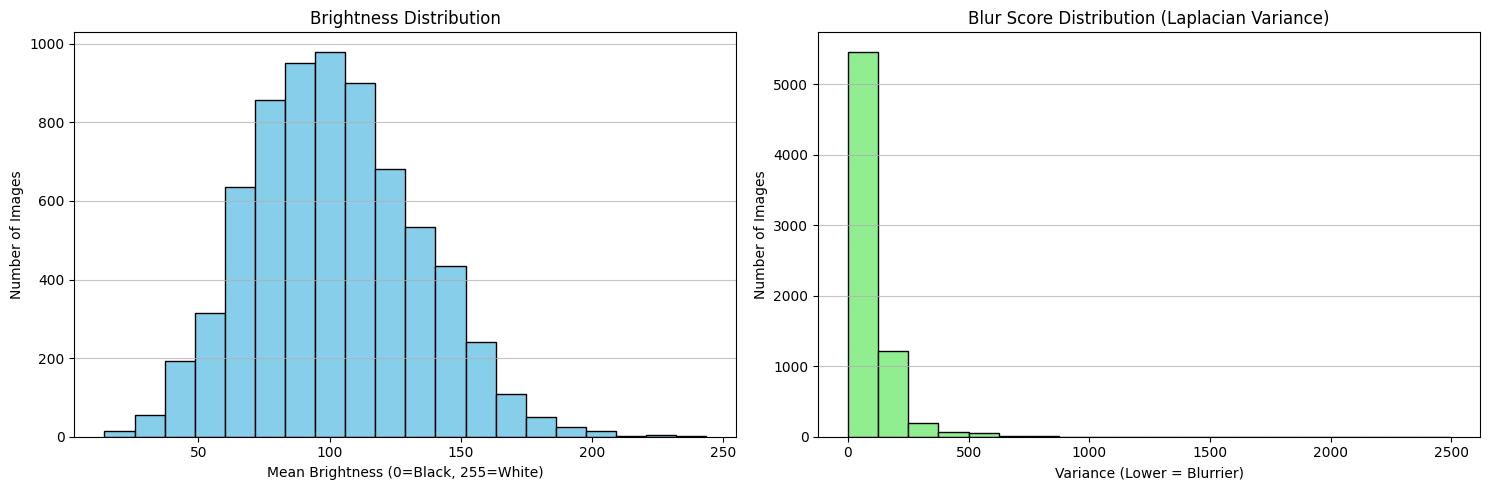

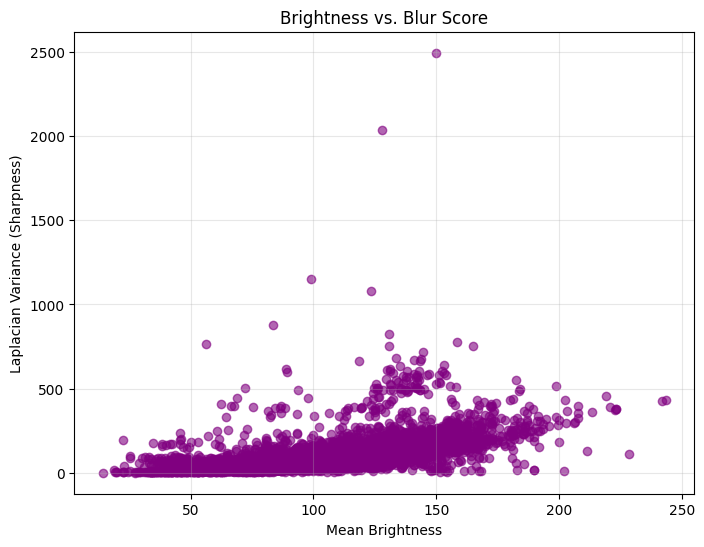

In [ ]:
import cv2
import numpy as np
import os
import random
import glob
import matplotlib.pyplot as plt
from pathlib import Path

def get_image_metrics(image_path):
    """
    Loads an image, auto-crops the fundus, and calculates raw QA metrics.
    """
    image = cv2.imread(image_path)
    if image is None:
        return None, None

    # Auto-crop logic
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None # Totally black image

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    cropped_gray = gray[y:y+h, x:x+w]
    cropped_mask = mask[y:y+h, x:x+w]

    # Safety check in case of weird crops
    if np.sum(cropped_mask > 0) == 0:
        return None, None

    # Calculate Metrics
    mean_brightness = np.mean(cropped_gray[cropped_mask > 0])
    blur_score = cv2.Laplacian(cropped_gray, cv2.CV_64F).var()

    return mean_brightness, blur_score

# --- SCRIPT SETUP ---
# CHANGE THIS to the path where your ODIR images are stored
odir_folder_path = "/content/drive/MyDrive/CV-2026/Training Set/Images"
image_count = len([f for f in Path(odir_folder_path).iterdir()
                   if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif']])

print(f"Total images: {image_count}")
# Grab all image files (assuming they are .jpg, change if they are .png)
all_images = glob.glob(os.path.join(odir_folder_path, "*.jpg"))

# Randomly sample 50 images to process (adjust this number up if it runs fast!)
sample_size = max(50, len(all_images))
sampled_images = random.sample(all_images, sample_size)

brightness_scores = []
blur_scores = []
valid_images = []

print(f"Processing {sample_size} images...")

for img_path in sampled_images:
    brightness, blur = get_image_metrics(img_path)
    if brightness is not None and blur is not None:
        brightness_scores.append(brightness)
        blur_scores.append(blur)
        valid_images.append(img_path)

print("Done processing. Plotting results...")

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Brightness Distribution
ax1.hist(brightness_scores, bins=20, color='skyblue', edgecolor='black')
ax1.set_title('Brightness Distribution')
ax1.set_xlabel('Mean Brightness (0=Black, 255=White)')
ax1.set_ylabel('Number of Images')
ax1.grid(axis='y', alpha=0.75)

# Plot 2: Blur Distribution (Laplacian Variance)
ax2.hist(blur_scores, bins=20, color='lightgreen', edgecolor='black')
ax2.set_title('Blur Score Distribution (Laplacian Variance)')
ax2.set_xlabel('Variance (Lower = Blurrier)')
ax2.set_ylabel('Number of Images')
ax2.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

# Scatter plot to see relationship
plt.figure(figsize=(8, 6))
plt.scatter(brightness_scores, blur_scores, alpha=0.6, c='purple')
plt.title('Brightness vs. Blur Score')
plt.xlabel('Mean Brightness')
plt.ylabel('Laplacian Variance (Sharpness)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import cv2
import numpy as np
import os
import glob
import shutil
from tqdm import tqdm

def evaluate_and_crop(image_path, blur_thresh=15.0, dark_thresh=35.0, bright_thresh=190.0):
    """
    Evaluates an image, crops out the black background, and returns
    the cropped image and its Quality Assurance (QA) status.
    """
    # 1. Load the image
    image = cv2.imread(image_path)
    if image is None:
        return None, "FAILED_Unreadable"

    # 2. Create a binary mask to find the circular fundus
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    # 3. Find contours and locate the largest one (the retina)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, "FAILED_TotallyBlack"

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    # 4. Crop the image, grayscale, and mask tightly around the bounding box
    cropped_img = image[y:y+h, x:x+w]
    cropped_gray = gray[y:y+h, x:x+w]
    cropped_mask = mask[y:y+h, x:x+w]

    # Safety check: ensure the crop actually contains non-black pixels
    if np.sum(cropped_mask > 0) == 0:
        return None, "FAILED_CropError"

    # 5. QA Check 1: Brightness
    # Calculate mean brightness ONLY inside the actual retina mask, ignoring padded corners
    mean_brightness = np.mean(cropped_gray[cropped_mask > 0])

    if mean_brightness < dark_thresh:
        return cropped_img, f"FAILED_Dark_{mean_brightness:.0f}"
    if mean_brightness > bright_thresh:
        return cropped_img, f"FAILED_Bright_{mean_brightness:.0f}"

    # 6. QA Check 2: Blur (Laplacian Variance)
    blur_score = cv2.Laplacian(cropped_gray, cv2.CV_64F).var()

    if blur_score < blur_thresh:
        return cropped_img, f"FAILED_Blurry_{blur_score:.0f}"

    # If it survives all checks, it passes
    return cropped_img, "PASSED"


# ==========================================
# CONFIGURATION - CHANGE THESE PATHS
# ==========================================
# The folder containing your raw 7,000 images
input_folder = "/content/drive/MyDrive/CV-2026/Training Set/Images"

# The folder where you want the processed images to go
output_base = "/content/drive/MyDrive/CV-2026/Processed_ODIR_Dataset"
# ==========================================

passed_dir = os.path.join(output_base, "passed_qa")
failed_dir = os.path.join(output_base, "failed_qa")

# Safely create or overwrite the output directories
for d in [passed_dir, failed_dir]:
    if os.path.exists(d):
        print(f"Clearing existing directory: {d}")
        shutil.rmtree(d)
    os.makedirs(d)

# Grab all image files
all_images = glob.glob(os.path.join(input_folder, "*.jpg"))
# If they are .png, change the above line to "*.png"

print(f"Found {len(all_images)} images. Starting processing...")

pass_count = 0
fail_count = 0

# Run the pipeline with a progress bar
for img_path in tqdm(all_images, desc="Processing Images"):
    filename = os.path.basename(img_path)
    cropped_img, status = evaluate_and_crop(img_path)

    if status == "PASSED":
        # Save clean image
        save_path = os.path.join(passed_dir, filename)
        cv2.imwrite(save_path, cropped_img)
        pass_count += 1
    else:
        # Save failed image with the reason tagged in the filename
        fail_filename = f"{status}_{filename}"
        save_path = os.path.join(failed_dir, fail_filename)

        # Only save if we actually have an image array (not totally unreadable)
        if cropped_img is not None:
            cv2.imwrite(save_path, cropped_img)
        fail_count += 1

print("\n" + "="*40)
print("PIPELINE COMPLETE")
print("="*40)
print(f"Passed: {pass_count} images ({(pass_count/len(all_images))*100:.1f}%)")
print(f"Failed: {fail_count} images ({(fail_count/len(all_images))*100:.1f}%)")
print(f"Your clean SSL dataset is ready in:\n{passed_dir}")

Found 7000 images. Starting processing...


Processing Images: 100%|██████████| 7000/7000 [09:46<00:00, 11.93it/s]


PIPELINE COMPLETE
Passed: 6501 images (92.9%)
Failed: 499 images (7.1%)
Your clean SSL dataset is ready in:
/content/drive/MyDrive/CV-2026/Processed_ODIR_Dataset/passed_qa


## 3. Configuration

In [19]:
import cv2
import numpy as np

def pad_to_square(image):
    """
    Pads a rectangular image with black borders to make it a perfect square,
    preserving the original aspect ratio and anatomical geometry.
    """
    h, w = image.shape[:2]
    if h == w:
        return image

    size = max(h, w)

    # Calculate padding for both sides to keep the eye centered
    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    # Apply black padding (0,0,0)
    square_image = cv2.copyMakeBorder(
        image, top, bottom, left, right,
        cv2.BORDER_CONSTANT, value=[0, 0, 0]
    )

    return square_image

In [ ]:
import cv2
import os
import glob
from tqdm import tqdm

def apply_clahe_and_resize(image_path, target_size=(224, 224), clip_limit=2.0, grid_size=(8, 8)):
    """
    Loads an image, applies CLAHE to the lightness channel, and resizes it.
    """
    # 1. Load the image
    image = cv2.imread(image_path)
    if image is None:
        return None

    # 2. Convert to LAB Color Space
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    # 3. Split the channels (L, A, B)
    l_channel, a_channel, b_channel = cv2.split(lab)

    # 4. Create and apply CLAHE specifically to the L-channel (Lightness)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    cl = clahe.apply(l_channel)

    # 5. Merge the CLAHE enhanced L-channel with original A and B channels
    merged_lab = cv2.merge((cl, a_channel, b_channel))

    # 6. Convert back to standard BGR color space
    final_image = cv2.cvtColor(merged_lab, cv2.COLOR_LAB2BGR)

    # 7. Pad to square first!
    squared_image = pad_to_square(final_image)

    # NOW resize for PyTorch
    resized_image = cv2.resize(squared_image, target_size, interpolation=cv2.INTER_CUBIC)

    return resized_image

# ==========================================
# CONFIGURATION
# ==========================================
input_folder = "/content/drive/MyDrive/CV-2026/Processed_ODIR_Dataset/passed_qa"
output_folder = "/content/drive/MyDrive/CV-2026/Final_SSL_Data"

# Target resolution. 224x224 is standard for ResNet/ViT.
# If using a high-res model for small lesions, change to (384, 384).
TARGET_RESOLUTION = (224, 224)
# ==========================================

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

clean_images = glob.glob(os.path.join(input_folder, "*.jpg"))
print(f"Applying CLAHE to {len(clean_images)} images...")

for img_path in tqdm(clean_images, desc="Running CLAHE Pipeline"):
    filename = os.path.basename(img_path)

    # Process the image
    processed_img = apply_clahe_and_resize(img_path, target_size=TARGET_RESOLUTION)

    # Save to the final folder
    if processed_img is not None:
        save_path = os.path.join(output_folder, filename)
        cv2.imwrite(save_path, processed_img)

print("\nPipeline Complete. Your dataset is perfectly uniform, enhanced, and ready for training!")

Applying CLAHE to 6501 images...


Running CLAHE Pipeline: 100%|██████████| 6501/6501 [06:46<00:00, 16.00it/s]


Pipeline Complete. Your dataset is perfectly uniform, enhanced, and ready for training!


## 2. Configuration

In [5]:
from dataclasses import dataclass
import torch

# ──────────────────────────────────────────
# ODIR Disease Labels (Moved here so Config can see it!)
# ──────────────────────────────────────────
DISEASE_LABELS = [
    "Normal",
    "Diabetes",
    "Glaucoma",
    "Hypertension",
]
NUM_CLASSES = len(DISEASE_LABELS)

# ──────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────
@dataclass
class Config:
    """All-in-one configuration."""

    # Data Paths (UPDATED)
    ssl_data_root: str = "/content/drive/MyDrive/CV-2026/Final_SSL_Data"  # Your clean, CLAHE images
    annotation_file: str = "/content/drive/MyDrive/CV-2026/Training_Set/Annotation/training_annotation.xlsx" # Path to your labels

    image_size: int = 224
    num_workers: int = 2
    train_ratio: float = 0.7
    val_ratio: float = 0.15
    seed: int = 42

    backbone_name: str = "resnet50"

    simclr_projection_dim: int = 128
    simclr_hidden_dim: int = 2048
    simclr_temperature: float = 0.07

    byol_projection_dim: int = 256
    byol_hidden_dim: int = 4096
    byol_prediction_dim: int = 256
    byol_ema_decay: float = 0.996
    byol_ema_decay_end: float = 1.0

    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ssl_batch_size: int = 128
    ssl_lr: float = 1e-3
    ssl_weight_decay: float = 1e-6
    ssl_warmup_epochs: int = 10
    ssl_epochs: int = 50
    ssl_momentum: float = 0.9
    gradient_clip: float = 1.0
    mixed_precision: bool = True

    ft_batch_size: int = 32
    ft_lr: float = 1e-3
    ft_weight_decay: float = 1e-6
    ft_warmup_epochs: int = 5
    ft_epochs: int = 60
    ft_freeze_epochs: int = 10
    ft_dropout: float = 0.5
    ft_threshold: float = 0.5
    ft_bce_weight: float = 0.6
    ft_dice_weight: float = 0.4
    ft_label_smoothing: float = 0.1
    ft_early_stopping_patience: int = 10

cfg = Config()
print(f"Config initialized: {NUM_CLASSES} classes, {cfg.device} device")

Config initialized: 4 classes, cuda device


## 3. Data Augmentations (Fundus-Aware)

In [6]:
import torchvision.transforms as transforms

# ──────────────────────────────────────────
# Medical SSL Augmentations (No vertical flips, no hue shifts)
# ──────────────────────────────────────────
class MedicalSSLAugmentation:
    """Unified SSL augmentation pipeline (works for both SimCLR and BYOL)."""
    def __init__(self, image_size=224):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.6, 1.0)), # Keep more of the retina
            transforms.RandomHorizontalFlip(),
            # DELETED RandomVerticalFlip()
            transforms.RandomRotation(degrees=30), # Gentle natural rotation
            transforms.RandomApply([
                # Mild brightness/contrast only. NO HUE SHIFT (hue=0.0).
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.0)
            ], p=0.8),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def __call__(self, x):
        return self.transform(x), self.transform(x)

# ──────────────────────────────────────────
# Fine-tuning Augmentations (Lighter, medical safe)
# ──────────────────────────────────────────
class FinetuneAugmentation:
    """Augmentation for fine-tuning."""
    def __init__(self, image_size=224, is_train=True):
        if is_train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(image_size, scale=(0.85, 1.0)),
                transforms.RandomHorizontalFlip(),
                # DELETED RandomVerticalFlip()
                transforms.RandomApply([
                    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.05, hue=0.0)
                ], p=0.5),
                transforms.RandomAffine(degrees=15, translate=(0.05, 0.05)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((image_size, image_size)), # Images are already squared, just resize
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

    def __call__(self, x):
        return self.transform(x)

print("Medical Augmentations initialized.")

Medical Augmentations initialized.


## 4. ODIR Dataset Loader

In [7]:
import torch
from torch.utils.data import Dataset
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image

class ODIRDataset(Dataset):
    """
    Simplified ODIR dataset for pre-processed, clean images.
    """
    def __init__(self, ssl_data_root, annotation_file=None, transform=None, mode="finetune"):
        self.data_root = Path(ssl_data_root)
        self.annotation_file = Path(annotation_file) if annotation_file else None
        self.transform = transform
        self.mode = mode
        self.samples = self._load_samples()

    def _load_samples(self):
        samples = []

        # SSL MODE: Load every single clean image. No labels needed.
        if self.mode == "ssl":
            for f in sorted(self.data_root.glob("*.jpg")) + sorted(self.data_root.glob("*.png")):
                samples.append({"path": str(f), "labels": np.zeros(NUM_CLASSES, dtype=np.float32)})
            print(f"[DATA] Loaded {len(samples)} clean images for SSL pre-training.")
            return samples

        # FINETUNE MODE: Match annotations to the clean images
        df = pd.read_excel(self.annotation_file) if str(self.annotation_file).endswith('.xlsx') else pd.read_csv(self.annotation_file)
        label_cols = self._detect_label_cols(df)

        for _, row in df.iterrows():
            for eye in ["left", "right"]:
                path = self._resolve_path(row, eye)
                if path and path.exists():
                    labels = self._extract_labels(row, label_cols)
                    samples.append({"path": str(path), "labels": labels})

        print(f"[DATA] Loaded {len(samples)} labeled fundus images for Fine-tuning")
        return samples

    def _resolve_path(self, row, eye):
        """Look for the image in our single clean folder."""
        basename = row.get("ID") or row.get("Patient ID") or "unknown"
        for ext in [".jpg", ".png", ".jpeg"]:
            for pattern in [f"{basename}_{eye[0].upper()}{ext}",
                           f"{basename}_{eye.upper()}{ext}",
                           f"{basename}_{eye}{ext}"]:
                p = self.data_root / pattern
                if p.exists():
                    return p
        return None

    def _detect_label_cols(self, df):
        selected_cols = ["N", "D", "G", "H"]
        found = [c for c in selected_cols if c in df.columns]
        if found: return found
        return [c for c in df.columns if df[c].dtype in [int, float] and df[c].nunique() <= 2][:NUM_CLASSES]

    def _extract_labels(self, row, label_cols):
        labels = np.zeros(NUM_CLASSES, dtype=np.float32)
        col_map = {"N": 0, "D": 1, "G": 2, "H": 3}
        for col in label_cols:
            if col in col_map:
                labels[col_map[col]] = float(row.get(col, 0))

        keyword_map = {
            0: ["normal"],
            1: ["diabetes", "diabetic", "retinopathy", "nonproliferative", "proliferative", "macular edema"],
            2: ["glaucoma", "optic", "cup"],
            3: ["hypertension", "hypertensive"],
        }
        note = str(row.get("Diagnostic Keywords", "")).lower()
        for class_idx, keywords in keyword_map.items():
            if any(kw in note for kw in keywords):
                labels[class_idx] = 1.0
        return labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # We REMOVED the try/except block. We trust our preprocessing!
        img = Image.open(sample["path"]).convert("RGB")

        if self.mode == "ssl":
            return self.transform(img)
        else:
            img = self.transform(img)
            return img, torch.tensor(sample["labels"], dtype=torch.float32)

print("Dataset loader initialized successfully.")

Dataset loader initialized successfully.


In [8]:
import numpy as np
from torch.utils.data import DataLoader, Subset

def get_dataloaders(mode="finetune", train_transform=None, val_transform=None, ssl_transform=None):
    """Creates the DataLoaders using the new ssl_data_root and annotation_file paths."""
    if mode == "ssl":
        ds = ODIRDataset(ssl_data_root=cfg.ssl_data_root, transform=ssl_transform, mode="ssl")
        train_size = int(0.9 * len(ds))
        train_ds, val_ds = torch.utils.data.random_split(ds, [train_size, len(ds) - train_size])
        return {
            "train": DataLoader(train_ds, batch_size=cfg.ssl_batch_size, shuffle=True,
                               num_workers=cfg.num_workers, pin_memory=True, drop_last=True),
            "val": DataLoader(val_ds, batch_size=cfg.ssl_batch_size, shuffle=False,
                             num_workers=cfg.num_workers, pin_memory=True),
        }
    else:  # finetune
        ds = ODIRDataset(ssl_data_root=cfg.ssl_data_root, annotation_file=cfg.annotation_file, transform=None, mode="finetune")

        n = len(ds)
        indices = np.arange(n)
        np.random.seed(cfg.seed)
        np.random.shuffle(indices)

        train_n = int(cfg.train_ratio * n)
        val_n = int(cfg.val_ratio * n)

        train_idx = indices[:train_n]
        val_idx = indices[train_n:train_n + val_n]
        test_idx = indices[train_n + val_n:]

        class TransformedSubset(Subset):
            def __init__(self, dataset, indices, transform):
                super().__init__(dataset, indices)
                self.transform = transform
            def __getitem__(self, idx):
                img, lbl = self.dataset[self.indices[idx]]
                return self.transform(img) if self.transform else img, lbl

        train_ds = TransformedSubset(ds, train_idx, train_transform)
        val_ds = TransformedSubset(ds, val_idx, val_transform)
        test_ds = TransformedSubset(ds, test_idx, val_transform) # Test uses val transforms

        return {
            "train": DataLoader(train_ds, batch_size=cfg.ft_batch_size, shuffle=True,
                               num_workers=cfg.num_workers, pin_memory=True),
            "val": DataLoader(val_ds, batch_size=cfg.ft_batch_size, shuffle=False,
                             num_workers=cfg.num_workers, pin_memory=True),
            "test": DataLoader(test_ds, batch_size=cfg.ft_batch_size, shuffle=False,
                              num_workers=cfg.num_workers, pin_memory=True),
            "full_dataset": ds,
        }

print("get_dataloaders function is successfully loaded into memory!")

get_dataloaders function is successfully loaded into memory!


## 5. Backbone & Models

In [9]:
import torch.nn as nn
import torchvision.models as models

def get_backbone(name="resnet50"):
    """Get pretrained backbone."""
    model = models.resnet50(pretrained=True)
    model.fc = nn.Identity()
    model.feature_dim = 2048
    return model

class MultiLabelClassifier(nn.Module):
    """Multi-label classifier head."""
    def __init__(self, backbone, num_classes=NUM_CLASSES, dropout=0.5, freeze=False):
        super().__init__()
        self.backbone = backbone
        self.freeze_backbone = freeze
        if freeze:
            for p in backbone.parameters():
                p.requires_grad = False

        self.head = nn.Sequential(
            nn.Linear(backbone.feature_dim, 512), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)

    def unfreeze(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

print("Backbone models initialized.")

Backbone models initialized.


## 6. SSL Methods: SimCLR, BYOL

In [10]:
import copy
import math
import torch.nn.functional as F

# ══════════════════════════════════════════
# SimCLR
# ══════════════════════════════════════════
class SimCLR(nn.Module):
    def __init__(self, backbone_name="resnet50", proj_dim=128, hidden_dim=2048, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        self.backbone = get_backbone(backbone_name)
        fd = self.backbone.feature_dim
        self.projector = nn.Sequential(
            nn.Linear(fd, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(True),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, x1, x2):
        z1 = F.normalize(self.projector(self.backbone(x1)), dim=1)
        z2 = F.normalize(self.projector(self.backbone(x2)), dim=1)
        return self._nt_xent(z1, z2), z1, z2

    def _nt_xent(self, z1, z2):
        B = z1.shape[0]
        z = torch.cat([z1, z2], dim=0)
        sim = torch.mm(z, z.T) / self.temperature
        mask = torch.eye(2*B, device=z.device, dtype=torch.bool)
        sim.masked_fill_(mask, float('-inf'))
        pos_idx = torch.cat([torch.arange(B, 2*B), torch.arange(0, B)]).to(z.device)
        pos_sim = sim[torch.arange(2*B, device=z.device), pos_idx]
        return (-pos_sim + torch.logsumexp(sim, dim=1)).mean()

# ══════════════════════════════════════════
# BYOL
# ══════════════════════════════════════════
class BYOL(nn.Module):
    def __init__(self, backbone_name="resnet50", proj_dim=256, hidden_dim=4096,
                 pred_dim=256, ema_decay=0.996):
        super().__init__()
        self.ema_decay = ema_decay

        # Online network
        self.online_backbone = get_backbone(backbone_name)
        fd = self.online_backbone.feature_dim
        self.online_projector = nn.Sequential(
            nn.Linear(fd, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(True),
            nn.Linear(hidden_dim, proj_dim), nn.BatchNorm1d(proj_dim),
        )
        self.predictor = nn.Sequential(
            nn.Linear(proj_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(True),
            nn.Linear(hidden_dim, proj_dim),
        )

        # Target network (EMA)
        self.target_backbone = copy.deepcopy(self.online_backbone)
        self.target_projector = copy.deepcopy(self.online_projector)

        for p in self.target_backbone.parameters():
            p.requires_grad = False
        for p in self.target_projector.parameters():
            p.requires_grad = False

    def forward(self, x1, x2):
        # Online
        z1_online = self.online_projector(self.online_backbone(x1))
        h1 = self.predictor(z1_online)

        # Target
        with torch.no_grad():
            z2_target = self.target_projector(self.target_backbone(x2))

        loss = 2 - 2 * F.cosine_similarity(h1, z2_target, dim=1).mean()

        # Symmetry
        z2_online = self.online_projector(self.online_backbone(x2))
        h2 = self.predictor(z2_online)
        with torch.no_grad():
            z1_target = self.target_projector(self.target_backbone(x1))
        loss = loss + (2 - 2 * F.cosine_similarity(h2, z1_target, dim=1).mean())

        return loss / 2

    def update_target(self, decay):
        """Update target network via EMA."""
        for p_online, p_target in zip(self.online_backbone.parameters(),
                                        self.target_backbone.parameters()):
            p_target.data = decay * p_target.data + (1 - decay) * p_online.data
        for p_online, p_target in zip(self.online_projector.parameters(),
                                       self.target_projector.parameters()):
            p_target.data = decay * p_target.data + (1 - decay) * p_online.data

    @staticmethod
    def cosine_ema(start, end, step, total):
        """Cosine schedule for EMA decay."""
        return end + 0.5 * (start - end) * (1 + math.cos(math.pi * step / total))

print("SSL methods (SimCLR, BYOL) initialized.")

SSL methods (SimCLR, BYOL) initialized.


## 7. Losses & Metrics

In [11]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, average_precision_score

class CombinedLoss(nn.Module):
    """BCE + Dice for multi-label classification."""
    def __init__(self, bce_weight=0.6, dice_weight=0.4, label_smoothing=0.1, class_weights=None):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss(weight=class_weights, reduction='mean')
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # Label smoothing
        targets_smooth = targets * (1 - self.label_smoothing) + self.label_smoothing / 2

        bce_loss = self.bce(logits, targets_smooth)

        # Dice loss
        probs = torch.sigmoid(logits)
        dice_loss = 1 - (2 * (probs * targets_smooth).sum(dim=0) + 1e-8) / ((probs + targets_smooth).sum(dim=0) + 1e-8)
        dice_loss = dice_loss.mean()

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

def compute_metrics(y_true, y_pred, y_prob):
    """Compute multi-label metrics."""
    metrics = {}

    # Per-class AUC
    auc_scores = []
    for i in range(y_true.shape[1]):
        if len(np.unique(y_true[:, i])) > 1:
            auc = roc_auc_score(y_true[:, i], y_prob[:, i])
            auc_scores.append(auc)
    metrics['auc_macro'] = np.mean(auc_scores) if auc_scores else 0.0

    # F1 (macro)
    f1_scores = []
    for i in range(y_true.shape[1]):
        f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
        f1_scores.append(f1)
    metrics['f1_macro'] = np.mean(f1_scores)

    # Precision, Recall
    metrics['precision_macro'] = np.mean([precision_score(y_true[:, i], y_pred[:, i], zero_division=0) for i in range(y_true.shape[1])])
    metrics['recall_macro'] = np.mean([recall_score(y_true[:, i], y_pred[:, i], zero_division=0) for i in range(y_true.shape[1])])

    # Mean Average Precision
    map_scores = []
    for i in range(y_true.shape[1]):
        if len(np.unique(y_true[:, i])) > 1:
            ap = average_precision_score(y_true[:, i], y_prob[:, i])
            map_scores.append(ap)
    metrics['mAP'] = np.mean(map_scores) if map_scores else 0.0

    # Exact match
    metrics['exact_match'] = np.mean(np.all(y_true == y_pred, axis=1))

    return metrics

def compute_class_weights(dataset):
    """Compute class weights for imbalance."""
    labels = np.array([s['labels'] for s in dataset.samples])
    pos_counts = labels.sum(axis=0)
    neg_counts = (1 - labels).sum(axis=0)
    weights = (neg_counts + 1) / (pos_counts + 1)
    return torch.tensor(weights, dtype=torch.float32)

print("Loss and metrics initialized.")

Loss and metrics initialized.


## 8. Training Utilities

In [12]:
from torch.cuda.amp import GradScaler, autocast
import time

class EarlyStopping:
    """Early stopping callback."""
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True  # Stop
        return False

def get_cosine_schedule(optimizer, warmup_epochs, total_epochs, num_steps_per_epoch=1):
    """Cosine annealing with warmup."""
    from torch.optim.lr_scheduler import LambdaLR
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        return 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (total_epochs - warmup_epochs)))
    return LambdaLR(optimizer, lr_lambda)

print("Training utilities initialized.")

Training utilities initialized.


## 9. SSL Pretraining
Note: Only SimCLR (9a) and BYOL (9b) are used in this demo.

In [ ]:
import time
import copy
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms

# ──────────────────────────────────────
# 9a. SimCLR Pretraining (UPDATED FOR MEDICAL DATA)
# ──────────────────────────────────────
print("="*60)
print("  SimCLR Pretraining (Medical Transforms)")
print("="*60)

device = torch.device(cfg.device)

# 1. Use the NEW medically-safe augmentation
aug = MedicalSSLAugmentation(cfg.image_size)

# 2. Load the clean dataset (this automatically uses your new clean folder)
loaders = get_dataloaders(mode="ssl", ssl_transform=aug)

# 3. Initialize SimCLR
simclr = SimCLR(
    proj_dim=cfg.simclr_projection_dim,
    hidden_dim=cfg.simclr_hidden_dim,
    temperature=cfg.simclr_temperature,
).to(device)

opt = torch.optim.AdamW(simclr.parameters(), lr=cfg.ssl_lr, weight_decay=cfg.ssl_weight_decay)
sched = get_cosine_schedule(opt, cfg.ssl_warmup_epochs, cfg.ssl_epochs)
scaler = GradScaler(enabled=cfg.mixed_precision)

simclr_losses = []

# 4. Run the Training Loop
for epoch in range(cfg.ssl_epochs):
    simclr.train()
    total_loss, t0 = 0.0, time.time()

    for v1, v2 in loaders["train"]:
        v1, v2 = v1.to(device), v2.to(device)

        opt.zero_grad()
        with autocast(enabled=cfg.mixed_precision):
            loss, _, _ = simclr(v1, v2)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(simclr.parameters(), cfg.gradient_clip)
        scaler.step(opt)
        scaler.update()

        total_loss += loss.item()

    sched.step()
    avg = total_loss / len(loaders["train"])
    simclr_losses.append(avg)

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1}/{cfg.ssl_epochs} | Loss: {avg:.4f} | Time: {time.time()-t0:.1f}s")

# 5. Save the trained backbone
trained_backbones = {}
trained_backbones["simclr"] = copy.deepcopy(simclr.backbone.state_dict())
print(f"SimCLR training complete. Final loss: {simclr_losses[-1]:.4f}")

  SimCLR Pretraining (Medical Transforms)
[DATA] Loaded 6501 clean images for SSL pre-training.


/tmp/ipykernel_736/3827520139.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.mixed_precision)
/tmp/ipykernel_736/3827520139.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):


  Epoch 1/50 | Loss: 0.6050 | Time: 264.5s
  Epoch 10/50 | Loss: 0.0337 | Time: 216.6s
  Epoch 20/50 | Loss: 0.0074 | Time: 220.9s
  Epoch 30/50 | Loss: 0.0056 | Time: 213.8s
  Epoch 40/50 | Loss: 0.0032 | Time: 218.0s
  Epoch 50/50 | Loss: 0.0032 | Time: 216.8s
SimCLR training complete. Final loss: 0.0032


In [ ]:
import time
import copy
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast

# ──────────────────────────────────────
# 9b. BYOL Pretraining (UPDATED FOR MEDICAL DATA)
# ──────────────────────────────────────
print("\n" + "="*60)
print("  BYOL Pretraining (Medical Transforms)")
print("="*60)

device = torch.device(cfg.device)

# 1. Use the NEW medically-safe augmentation
aug = MedicalSSLAugmentation(cfg.image_size)

# 2. Load the clean dataset
loaders = get_dataloaders(mode="ssl", ssl_transform=aug)

# 3. Initialize BYOL
byol = BYOL(
    proj_dim=cfg.byol_projection_dim,
    hidden_dim=cfg.byol_hidden_dim,
    pred_dim=cfg.byol_prediction_dim,
    ema_decay=cfg.byol_ema_decay,
).to(device)

online_params = list(byol.online_backbone.parameters()) + list(byol.online_projector.parameters()) + list(byol.predictor.parameters())
opt = torch.optim.AdamW(online_params, lr=cfg.ssl_lr, weight_decay=cfg.ssl_weight_decay)
sched = get_cosine_schedule(opt, cfg.ssl_warmup_epochs, cfg.ssl_epochs)
scaler = GradScaler(enabled=cfg.mixed_precision)

total_steps = cfg.ssl_epochs * len(loaders["train"])
step = 0
byol_losses = []

# 4. Run the Training Loop
for epoch in range(cfg.ssl_epochs):
    byol.train()
    total_loss, t0 = 0.0, time.time()

    for v1, v2 in loaders["train"]:
        v1, v2 = v1.to(device), v2.to(device)

        opt.zero_grad()
        with autocast(enabled=cfg.mixed_precision):
            loss = byol(v1, v2)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(online_params, cfg.gradient_clip)
        scaler.step(opt)
        scaler.update()

        # Update target network via EMA
        decay = BYOL.cosine_ema(cfg.byol_ema_decay, cfg.byol_ema_decay_end, step, total_steps)
        byol.update_target(decay)

        step += 1
        total_loss += loss.item()

    sched.step()
    avg = total_loss / len(loaders["train"])
    byol_losses.append(avg)

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1}/{cfg.ssl_epochs} | Loss: {avg:.4f} | Time: {time.time()-t0:.1f}s")

# 5. Save the trained backbone
trained_backbones["byol"] = copy.deepcopy(byol.online_backbone.state_dict())
print(f"BYOL training complete. Final loss: {byol_losses[-1]:.4f}")


  BYOL Pretraining (Medical Transforms)
[DATA] Loaded 6501 clean images for SSL pre-training.


/tmp/ipykernel_736/1198141074.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.mixed_precision)
/tmp/ipykernel_736/1198141074.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):


  Epoch 1/50 | Loss: 1.3654 | Time: 250.4s
  Epoch 10/50 | Loss: 0.1167 | Time: 212.2s
  Epoch 20/50 | Loss: 0.0571 | Time: 214.8s
  Epoch 30/50 | Loss: 0.0400 | Time: 220.4s
  Epoch 40/50 | Loss: 0.0317 | Time: 206.5s
  Epoch 50/50 | Loss: 0.0293 | Time: 216.0s
BYOL training complete. Final loss: 0.0293


In [28]:
import torch
import os

# Create a permanent Models folder in your Google Drive
drive_model_dir = "/content/drive/MyDrive/CV-2026/Saved_Models"
os.makedirs(drive_model_dir, exist_ok=True)

# Save the SimCLR and BYOL backbones permanently
if "simclr" in trained_backbones:
    torch.save(trained_backbones["simclr"], f"{drive_model_dir}/simclr_backbone_epoch50.pth")
    print(f"✅ SimCLR securely saved to {drive_model_dir}")

if "byol" in trained_backbones:
    torch.save(trained_backbones["byol"], f"{drive_model_dir}/byol_backbone_epoch50.pth")
    print(f"✅ BYOL securely saved to {drive_model_dir}")

✅ SimCLR securely saved to /content/drive/MyDrive/CV-2026/Saved_Models
✅ BYOL securely saved to /content/drive/MyDrive/CV-2026/Saved_Models


In [13]:
import torch
import os

# Define the directory where models are saved in Google Drive
drive_model_dir = "/content/drive/MyDrive/CV-2026/Saved_Models"

# Initialize trained_backbones dictionary if it doesn't exist
if 'trained_backbones' not in locals():
    trained_backbones = {}

# Load SimCLR backbone
simclr_path = os.path.join(drive_model_dir, "simclr_backbone_epoch50.pth")
if os.path.exists(simclr_path):
    trained_backbones["simclr"] = torch.load(simclr_path)
    print(f"Loaded SimCLR backbone from {simclr_path}")
else:
    print(f"SimCLR backbone not found at {simclr_path}")

# Load BYOL backbone
byol_path = os.path.join(drive_model_dir, "byol_backbone_epoch50.pth")
if os.path.exists(byol_path):
    trained_backbones["byol"] = torch.load(byol_path)
    print(f"Loaded BYOL backbone from {byol_path}")
else:
    print(f"BYOL backbone not found at {byol_path}")

print(f"Trained backbones available: {list(trained_backbones.keys())}")

Loaded SimCLR backbone from /content/drive/MyDrive/CV-2026/Saved_Models/simclr_backbone_epoch50.pth
Loaded BYOL backbone from /content/drive/MyDrive/CV-2026/Saved_Models/byol_backbone_epoch50.pth
Trained backbones available: ['simclr', 'byol']


NameError: name 'simclr_losses' is not defined

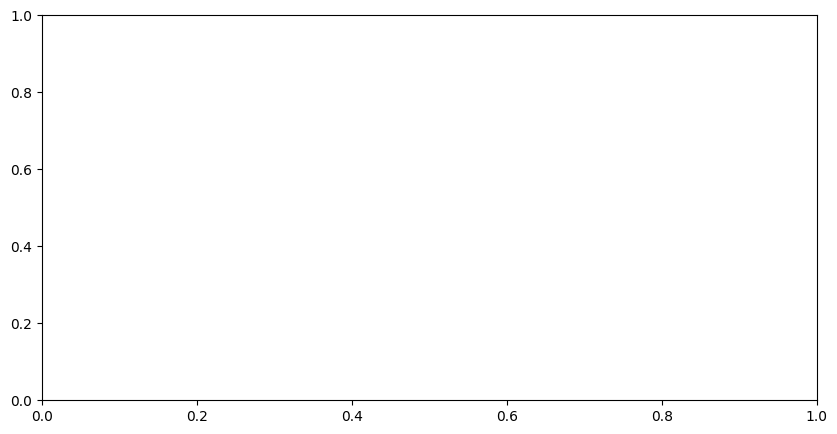

In [30]:
# ── Plot SSL pretraining losses ──
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(simclr_losses, label="SimCLR", marker='o', markersize=3, linewidth=2)
ax.plot(byol_losses, label="BYOL", marker='s', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("SSL Pretraining Losses", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Fine-Tuning & Evaluation

In [14]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class CleanDatasetWrapper(Dataset):
    """A multiprocessing-safe wrapper that guarantees transforms are applied."""
    def __init__(self, base_dataset, indices, transform):
        self.samples = base_dataset.samples
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        sample = self.samples[self.indices[idx]]
        img = Image.open(sample["path"]).convert("RGB")
        img = self.transform(img)
        return img, torch.tensor(sample["labels"], dtype=torch.float32)

def finetune_and_evaluate(method_name, backbone_state):
    """
    Fine-tune a pretrained backbone and evaluate on test set.
    Returns: (model, test_metrics, y_true, y_prob, y_pred, history)
    """
    print(f"\n{'='*50}")
    print(f"  Fine-tuning: {method_name.upper()}")
    print(f"{'='*50}")

    # Define device inside the function
    device = torch.device(cfg.device)

    # Data Transforms
    train_aug = FinetuneAugmentation(cfg.image_size, is_train=True)
    val_aug = FinetuneAugmentation(cfg.image_size, is_train=False)
    loaders = get_dataloaders(mode="finetune")

    # Bulletproof Fix: Rebuild datasets using a safe wrapper to avoid pickling/tuple issues
    base_ds = loaders["full_dataset"]
    train_idx = loaders["train"].dataset.indices
    val_idx = loaders["val"].dataset.indices
    test_idx = loaders["test"].dataset.indices

    train_ds = CleanDatasetWrapper(base_ds, train_idx, train_aug)
    val_ds = CleanDatasetWrapper(base_ds, val_idx, val_aug)
    test_ds = CleanDatasetWrapper(base_ds, test_idx, val_aug)

    loaders["train"] = DataLoader(train_ds, batch_size=cfg.ft_batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
    loaders["val"] = DataLoader(val_ds, batch_size=cfg.ft_batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
    loaders["test"] = DataLoader(test_ds, batch_size=cfg.ft_batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)

    # Class weights
    weights = compute_class_weights(loaders["full_dataset"]).to(device)

    # Model
    backbone = get_backbone()
    backbone.load_state_dict(backbone_state)
    model = MultiLabelClassifier(backbone, dropout=cfg.ft_dropout,
                                  freeze=(cfg.ft_freeze_epochs > 0)).to(device)
    criterion = CombinedLoss(cfg.ft_bce_weight, cfg.ft_dice_weight,
                             cfg.ft_label_smoothing, weights)

    # Optimizer (only head when frozen)
    if cfg.ft_freeze_epochs > 0:
        opt = torch.optim.AdamW(model.head.parameters(), lr=cfg.ft_lr, weight_decay=cfg.ft_weight_decay)
    else:
        opt = torch.optim.AdamW(model.parameters(), lr=cfg.ft_lr, weight_decay=cfg.ft_weight_decay)

    sched = get_cosine_schedule(opt, cfg.ft_warmup_epochs, cfg.ft_epochs)
    scaler = GradScaler(enabled=cfg.mixed_precision)
    early = EarlyStopping(cfg.ft_early_stopping_patience)

    history = {"train_loss": [], "val_loss": [], "val_auc": []}

    for epoch in range(cfg.ft_epochs):
        # Train
        model.train()
        total_loss = 0
        for x, y in loaders["train"]:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            with autocast(enabled=cfg.mixed_precision):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.gradient_clip)
            scaler.step(opt)
            scaler.update()
            total_loss += loss.item()

        # Validate
        model.eval()
        val_loss, y_val_true, y_val_prob = 0, [], []
        with torch.no_grad():
            for x, y in loaders["val"]:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item()
                y_val_true.append(y.cpu().numpy())
                y_val_prob.append(torch.sigmoid(logits).cpu().numpy())

        y_val_true = np.concatenate(y_val_true)
        y_val_prob = np.concatenate(y_val_prob)
        val_metrics = compute_metrics(y_val_true, (y_val_prob >= cfg.ft_threshold).astype(float), y_val_prob)

        avg_train_loss = total_loss / len(loaders["train"])
        avg_val_loss = val_loss / len(loaders["val"])

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_auc"].append(val_metrics["auc_macro"])

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{cfg.ft_epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | AUC: {val_metrics['auc_macro']:.4f}")

        sched.step()

        # Unfreeze after freeze period
        if epoch == cfg.ft_freeze_epochs - 1:
            model.unfreeze()
            opt = torch.optim.AdamW(model.parameters(), lr=cfg.ft_lr, weight_decay=cfg.ft_weight_decay)

        if early(avg_val_loss):
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Evaluate on test set
    model.eval()
    y_test_true, y_test_prob = [], []
    with torch.no_grad():
        for x, y in loaders["test"]:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            y_test_true.append(y.cpu().numpy())
            y_test_prob.append(torch.sigmoid(logits).cpu().numpy())

    y_test_true = np.concatenate(y_test_true)
    y_test_prob = np.concatenate(y_test_prob)
    y_test_pred = (y_test_prob >= cfg.ft_threshold).astype(float)

    test_metrics = compute_metrics(y_test_true, y_test_pred, y_test_prob)

    print(f"\nTest Results:")
    for k, v in test_metrics.items():
        print(f"  {k}: {v:.4f}")

    return model, test_metrics, y_test_true, y_test_prob, y_test_pred, history

# Fine-tune all two methods
results = {}
for method_name, backbone_state in trained_backbones.items():
    model, metrics, y_true, y_prob, y_pred, hist = finetune_and_evaluate(method_name, backbone_state)
    results[method_name] = {
        "model": model,
        "metrics": metrics,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "history": hist,
    }

print("\n" + "="*50)
print("Fine-tuning complete!")
print("="*50)


  Fine-tuning: SIMCLR
[DATA] Loaded 6499 labeled fundus images for Fine-tuning


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]
/tmp/ipykernel_33008/1824074752.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.mixed_precision)
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):


Epoch 1/60 | Train: 2.9582 | Val: 2.7868 | AUC: 0.6713


...

Epoch 1/60 | Train: 2.9143 | Val: 2.7353 | AUC: 0.7400


/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with

Epoch 10/60 | Train: 2.7515 | Val: 2.6873 | AUC: 0.7611


/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/tmp/ipykernel_33008/1824074752.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with

Early stopping at epoch 19

Test Results:
  auc_macro: 0.5882
  f1_macro: 0.0077
  precision_macro: 0.0893
  recall_macro: 0.0040
  mAP: 0.2209
  exact_match: 0.2889

Fine-tuning complete!


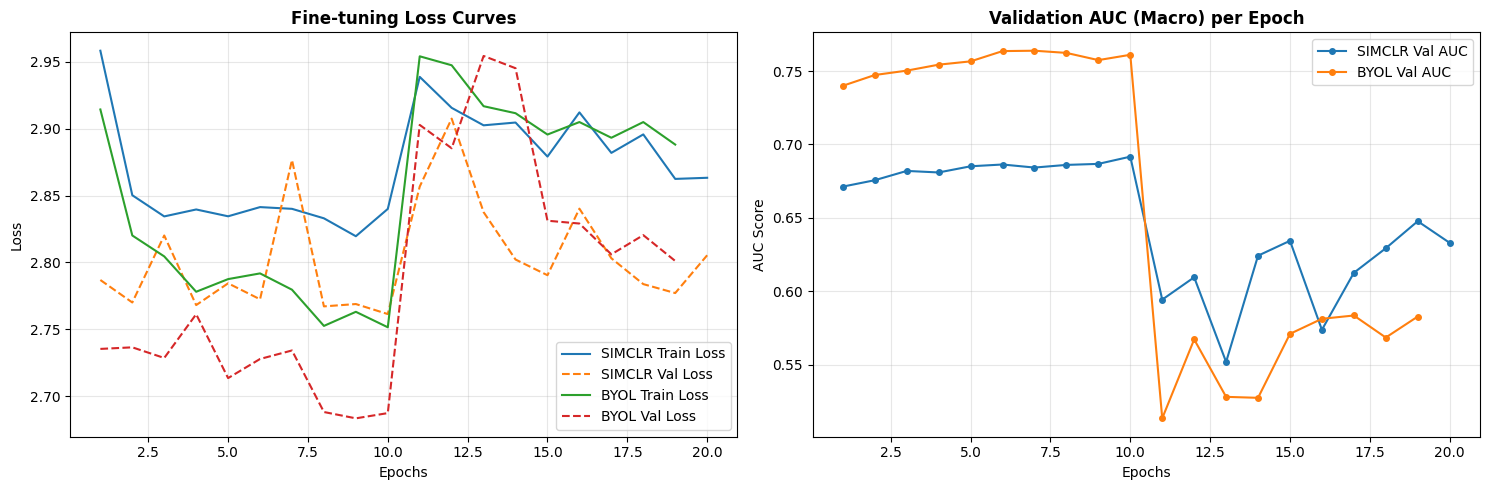

In [22]:
import matplotlib.pyplot as plt

# Create a figure with two subplots: Loss and AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Fine-tuning Loss (Training vs. Validation)
for method, r in results.items():
    epochs = range(1, len(r['history']['train_loss']) + 1)
    ax1.plot(epochs, r['history']['train_loss'], label=f'{method.upper()} Train Loss')
    ax1.plot(epochs, r['history']['val_loss'], '--', label=f'{method.upper()} Val Loss')

ax1.set_title('Fine-tuning Loss Curves', fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Validation AUC
for method, r in results.items():
    epochs = range(1, len(r['history']['val_auc']) + 1)
    ax2.plot(epochs, r['history']['val_auc'], marker='o', markersize=4, label=f'{method.upper()} Val AUC')

ax2.set_title('Validation AUC (Macro) per Epoch', fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('AUC Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Ensemble Fusion

In [15]:
# ── Combine predictions from both methods ──
from sklearn.metrics import roc_curve, auc as sk_auc, confusion_matrix

# Get a common y_true (they're all from the same test split)
y_true = list(results.values())[0]["y_true"]
all_probs = {m: r["y_prob"] for m, r in results.items()}

# Fusion strategies
def fuse(probs, strategy="average", weights=None):
    arrays = list(probs.values())
    if strategy == "average":
        return np.mean(arrays, axis=0)
    elif strategy == "weighted":
        total = sum(weights.values())
        return sum(weights[m] / total * probs[m] for m in probs)
    elif strategy == "max":
        return np.maximum.reduce(arrays)

# Use validation AUC as weights
fusion_weights = {m: r["metrics"]["auc_macro"] for m, r in results.items()}

print("Ensemble Results:")
print(f"{'Strategy':<12} {'AUC':>8} {'F1':>8} {'mAP':>8} {'Exact':>8}")
print("-" * 48)

ensemble_results = {}
for strat in ["average", "weighted", "max"]:
    fused = fuse(all_probs, strat, fusion_weights)
    preds = (fused >= cfg.ft_threshold).astype(float)
    m = compute_metrics(y_true, preds, fused)
    ensemble_results[strat] = {"probs": fused, "preds": preds, "metrics": m}
    print(f"{strat:<12} {m['auc_macro']:>8.4f} {m['f1_macro']:>8.4f} {m['mAP']:>8.4f} {m['exact_match']:>8.4f}")

# Also show individual results
print("\nIndividual Method Results:")
print(f"{'Method':<12} {'AUC':>8} {'F1':>8} {'mAP':>8} {'Exact':>8}")
print("-" * 48)
for method, r in results.items():
    m = r["metrics"]
    print(f"{method:<12} {m['auc_macro']:>8.4f} {m['f1_macro']:>8.4f} {m['mAP']:>8.4f} {m['exact_match']:>8.4f}")

# Best ensemble strategy
best_strat = max(ensemble_results, key=lambda k: ensemble_results[k]["metrics"]["auc_macro"])
print(f"\nBest ensemble strategy: {best_strat}")

Ensemble Results:
Strategy          AUC       F1      mAP    Exact
------------------------------------------------
average        0.6148   0.0030   0.2345   0.2889
weighted       0.6148   0.0045   0.2347   0.2889
max            0.5785   0.1025   0.2226   0.3443

Individual Method Results:
Method            AUC       F1      mAP    Exact
------------------------------------------------
simclr         0.6065   0.0948   0.2170   0.3422
byol           0.5882   0.0077   0.2209   0.2889

Best ensemble strategy: average


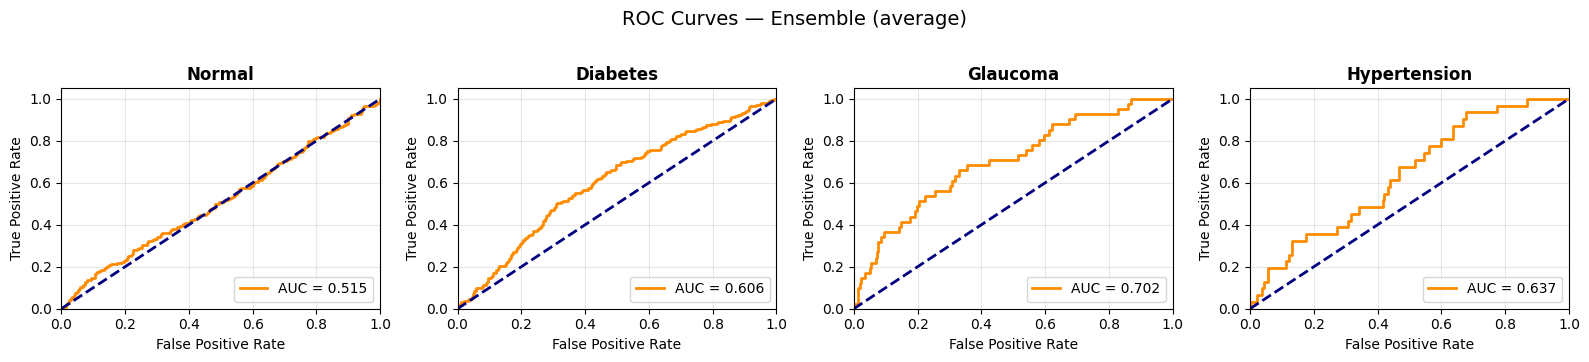

In [20]:
import matplotlib.pyplot as plt

# ── ROC curves (ensemble) ──
best_probs = ensemble_results[best_strat]["probs"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, (label, ax) in enumerate(zip(DISEASE_LABELS, axes)):
    fpr, tpr, _ = roc_curve(y_true[:, i], best_probs[:, i])
    roc_auc = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(label, fontweight='bold')
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.suptitle(f"ROC Curves — Ensemble ({best_strat})", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

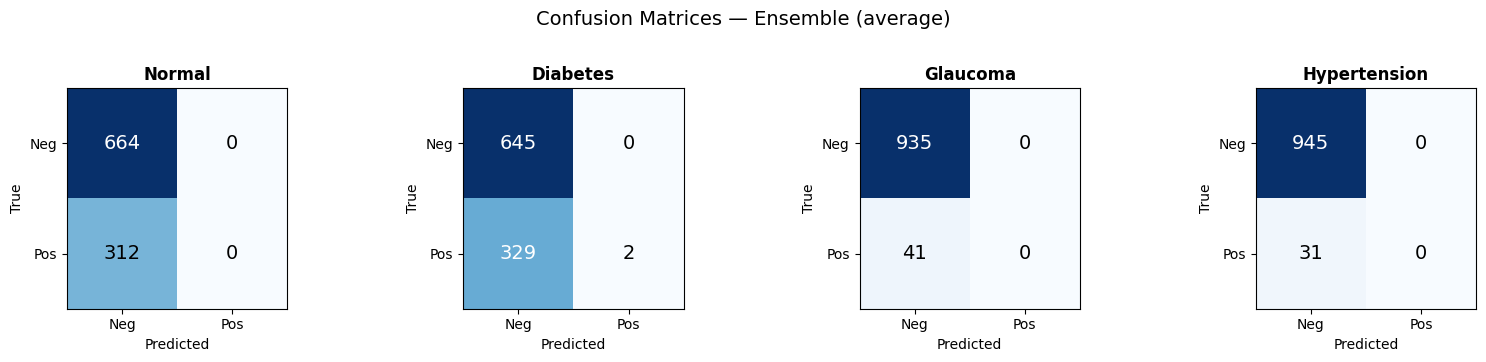

In [18]:
# ── Confusion matrices per class ──
best_preds = ensemble_results[best_strat]["preds"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, (label, ax) in enumerate(zip(DISEASE_LABELS, axes)):
    cm = confusion_matrix(y_true[:, i], best_preds[:, i], labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(label, fontweight="bold")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Neg", "Pos"]); ax.set_yticklabels(["Neg", "Pos"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r,c]), ha="center", va="center", fontsize=14,
                    color="white" if cm[r,c] > cm.max()/2 else "black")

plt.suptitle(f"Confusion Matrices — Ensemble ({best_strat})", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 13. Save Models & Results

In [21]:
import json
import os

# Create output directory
output_dir = "/content/drive/MyDrive/CV-2026/Saved_Models/ssl_results"
os.makedirs(output_dir, exist_ok=True)

# Save metrics
metrics_summary = {
    "individual": {m: r["metrics"] for m, r in results.items()},
    "ensemble": {s: r["metrics"] for s, r in ensemble_results.items()},
    "best_ensemble": best_strat,
}

with open(f"{output_dir}/metrics.json", "w") as f:
    json.dump({
        k: {
            method_name: {metric_name: float(metric_value) for metric_name, metric_value in metric_dict.items()}
            for method_name, metric_dict in vals.items()
        } if k in ["individual", "ensemble"]
        else vals
        for k, vals in metrics_summary.items()
    }, f, indent=2)
print(f"Metrics saved to {output_dir}/metrics.json")

# Save predictions
predictions = {
    "y_true": y_true.tolist(),
    "ensemble_probs": ensemble_results[best_strat]["probs"].tolist(),
    "ensemble_preds": ensemble_results[best_strat]["preds"].tolist(),
}

with open(f"{output_dir}/predictions.json", "w") as f:
    json.dump(predictions, f)
print(f"Predictions saved to {output_dir}/predictions.json")

# Save models
for method_name, r in results.items():
    torch.save(r["model"].state_dict(), f"{output_dir}/{method_name}_model.pth")
    print(f"Model saved: {output_dir}/{method_name}_model.pth")

print(f"\nAll results saved to {output_dir}")

Metrics saved to /content/drive/MyDrive/CV-2026/Saved_Models/ssl_results/metrics.json
Predictions saved to /content/drive/MyDrive/CV-2026/Saved_Models/ssl_results/predictions.json
Model saved: /content/drive/MyDrive/CV-2026/Saved_Models/ssl_results/simclr_model.pth
Model saved: /content/drive/MyDrive/CV-2026/Saved_Models/ssl_results/byol_model.pth

All results saved to /content/drive/MyDrive/CV-2026/Saved_Models/ssl_results


---
## Quick Reference
### Key hyperparameters to tune:
| Parameter | Location | Default | Notes |
|---|---|---|---|
| `cfg.ssl_epochs` | Config cell | 50 | Increase for better features |
| `cfg.ssl_batch_size` | Config cell | 128 | Larger = better for SimCLR |
| `cfg.ft_epochs` | Config cell | 60 | Early stopping handles this |
| `cfg.ft_freeze_epochs` | Config cell | 10 | Epochs with frozen backbone |
| `cfg.ft_lr` | Config cell | 1e-3 | For classifier head |
| `cfg.simclr_temperature` | Config cell | 0.07 | Lower = sharper contrasts |
### Common issues:
- **Low AUC**: Train SSL longer, use larger batch for SimCLR
- **Class imbalance**: Adjust class weights in `compute_class_weights()`
- **Memory issues**: Reduce batch sizes or image size to 192
### Methods used:
- **SimCLR** (9a): Contrastive learning with NT-Xent loss
- **BYOL** (9b): Bootstrap Your Own Latent (no negatives required)
- **Ensemble**: Average, weighted, or max voting fusion